# 01: Train Retriever And Build Indices

Цель: подготовить данные, дообучить MedCPT bi-encoder на hard negatives, построить все базовые индексы retrieval, сохранить промежуточные результаты в Google Drive как Colab cache и выгрузить финальные артефакты в S3/DVC через `artifact_push`.

Основные выходы:
- `data/processed`: `qa.jsonl`, `corpus.jsonl`, `splits.json`, `eval_queries.jsonl`, `qrels.tsv`
- `artifacts/models/retriever/trained_medcpt_biencoder`: `query_encoder`, `doc_encoder`, `training_summary.json`
- `artifacts/indices`: BM25, MiniLM dense, MedCPT, hybrid, trained MedCPT, graph metadata index
- `manifest.json`: единая карта путей для остальных ноутбуков

## S3/DVC remote artifact setup

S3/DVC is the source of truth for final artifacts. Google Drive can still be used as a Colab cache, but final indexes, checkpoints, and experiment outputs should be pushed through `artifact_push`.

In [5]:
import os
from pathlib import Path


os.environ["ARTIFACT_REMOTE_URI"] = (
    "s3://dmitrii-todorov-bucket/medical-rag-service/medquad-v1"
)
# To be REMOVED before deployment, only for local testing, for convenient use of secrets use Colab secrets
os.environ["AWS_ACCESS_KEY_ID"] = "YOUR_KEY_ID"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YOUR_SECRET_KEY"

try:
    from google.colab import userdata
except Exception:
    userdata = None


def find_local_env() -> Path | None:
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / ".env"
        if candidate.exists():
            return candidate
    return None


def load_local_env(path: str | Path | None = None):
    env_path = Path(path) if path is not None else find_local_env()
    print("Notebook cwd:", Path.cwd())
    if env_path is None or not env_path.exists():
        print("Local .env not found")
        return
    print("Loading local env from:", env_path)
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and value and not os.getenv(key):
            os.environ[key] = value


# In local VS Code/Jupyter, Colab Secrets are unavailable, so read repo .env.
if userdata is None:
    load_local_env()


def set_secret(name, default=None):
    if os.getenv(name):
        return
    if userdata is not None:
        try:
            value = userdata.get(name)
        except Exception:
            value = None
        if value:
            os.environ[name] = value
            return
    if default is not None:
        os.environ[name] = default


set_secret("AWS_ACCESS_KEY_ID")
set_secret("AWS_SECRET_ACCESS_KEY")
set_secret("AWS_REGION", "eu-north-1")
set_secret("ARTIFACT_DVC_REMOTE", "artifact_s3")
set_secret("ARTIFACT_REMOTE_URI")

print("DVC remote:", os.getenv("ARTIFACT_DVC_REMOTE"))
print("AWS region:", os.getenv("AWS_REGION"))
print("Artifact remote URI set:", bool(os.getenv("ARTIFACT_REMOTE_URI")))

DVC remote: artifact_s3
AWS region: eu-north-1
Artifact remote URI set: True


In [7]:
import platform
import torch

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError(
        "Enable a GPU in Colab: Runtime -> Change runtime type -> T4/A100."
    )
print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [ ]:
import platform
import torch

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError(
        "Enable a GPU in Colab: Runtime -> Change runtime type -> T4/A100."
    )
print("GPU:", torch.cuda.get_device_name(0))

In [8]:
from pathlib import Path
import datetime as dt
import json
import os
import shutil
import subprocess
import sys
import time

REPO_OWNER = "terrylimax"
REPO_NAME = "medical-rag-reranker"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
BRANCH = "main"

RUN_ID = os.environ.get("COLAB_RUN_ID", "medquad_full_v1")
USE_DRIVE = True

EVAL_SIZE = 300
TOP_K = 50
KS = "1,5,10,20,50"

TRAIN_BI_ENCODER = True
BI_ENCODER_EPOCHS = 2
BI_ENCODER_BATCH_SIZE = 8
ENCODE_BATCH_SIZE = 32
NEGATIVES_PER_QUERY = 4
HARD_NEGATIVE_POOL_SIZE = 50

PROJECT_DIR = Path("/content") / REPO_NAME
PROJECT_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RAW_MEDQUAD_PATH = PROJECT_DIR / "data" / "raw" / "medquad" / "train.parquet"

print("RUN_ID:", RUN_ID)

RUN_ID: medquad_full_v1


In [9]:
def mount_drive_or_content(use_drive: bool) -> Path:
    if not use_drive:
        return Path("/content") / "medical-rag-reranker-colab"

    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        return Path("/content/drive/MyDrive") / "medical-rag-reranker-colab"
    except Exception as exc:
        print("Drive mount failed; falling back to /content.")
        print(type(exc).__name__, str(exc))
        return Path("/content") / "medical-rag-reranker-colab"


DRIVE_BASE = mount_drive_or_content(USE_DRIVE)
DRIVE_ROOT = DRIVE_BASE / RUN_ID
DATA_DRIVE_DIR = DRIVE_ROOT / "data"
PROCESSED_DRIVE_DIR = DATA_DRIVE_DIR / "processed"
ARTIFACT_ROOT = DRIVE_ROOT / "artifacts"
INDEX_ROOT = ARTIFACT_ROOT / "indices"
MODEL_ROOT = ARTIFACT_ROOT / "models"
TRAINING_DATA_DIR = ARTIFACT_ROOT / "retriever_training"
RETRIEVER_DIR = MODEL_ROOT / "retriever" / "trained_medcpt_biencoder"
RUN_ROOT = DRIVE_ROOT / "runs"

for path in [
    DRIVE_ROOT,
    DATA_DRIVE_DIR,
    PROCESSED_DRIVE_DIR,
    ARTIFACT_ROOT,
    INDEX_ROOT,
    MODEL_ROOT,
    TRAINING_DATA_DIR,
    RETRIEVER_DIR,
    RUN_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DRIVE_ROOT / "manifest.json"
print("Drive root:", DRIVE_ROOT)
print("Manifest:", MANIFEST_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1
Manifest: /content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/manifest.json


In [10]:
def sh(args, *, cwd: Path | None = None) -> None:
    args = [str(arg) for arg in args]
    print("+", " ".join(args))
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["MEDICAL_RAG_PROGRESS"] = "1"
    env.setdefault("TQDM_MININTERVAL", "1")
    env.setdefault("TQDM_DYNAMIC_NCOLS", "1")

    proc = subprocess.Popen(
        args,
        cwd=None if cwd is None else str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=0,
        env=env,
    )
    assert proc.stdout is not None
    buffer: list[str] = []
    while True:
        ch = proc.stdout.read(1)
        if ch == "" and proc.poll() is not None:
            break
        if not ch:
            time.sleep(0.05)
            continue
        if ch == "\r":
            if buffer:
                print("".join(buffer), end="\r", flush=True)
                buffer = []
        elif ch == "\n":
            print("".join(buffer), flush=True)
            buffer = []
        else:
            buffer.append(ch)
    if buffer:
        print("".join(buffer), flush=True)

    returncode = proc.wait()
    if returncode:
        raise subprocess.CalledProcessError(returncode, args)


def run_project(command: str, overrides: list[str]) -> None:
    payload = json.dumps(overrides, ensure_ascii=False)
    sh(
        [
            sys.executable,
            "-u",
            "-m",
            "medical_rag_reranker.commands",
            command,
            "--overrides",
            payload,
        ],
        cwd=PROJECT_DIR,
    )


def base_overrides(*, artifacts_dir: Path | None = None) -> list[str]:
    if artifacts_dir is None:
        artifacts_dir = ARTIFACT_ROOT
    return [
        "data.use_dvc=false",
        "data.processed_dir=data/processed",
        f"paths.artifacts_dir={artifacts_dir}",
        f"paths.runs_dir={RUN_ROOT}",
        "run.prep_data.out_dir=data/processed",
    ]

In [11]:
if not (PROJECT_DIR / ".git").exists():
    sh(["git", "clone", "--branch", BRANCH, REPO_URL, PROJECT_DIR])
else:
    sh(["git", "fetch", "origin", BRANCH], cwd=PROJECT_DIR)
    sh(["git", "checkout", BRANCH], cwd=PROJECT_DIR)
    sh(["git", "pull", "--ff-only"], cwd=PROJECT_DIR)

os.chdir(PROJECT_DIR)
dependency_packages = [
    # Keep Colab aligned with pyproject.toml. Unpinned installs can pull
    # incompatible releases such as transformers 5.x or old datasets wheels.
    "transformers>=4.57.3,<5.0.0",
    "datasets>=4.4.2,<5.0.0",
    "tokenizers>=0.22.1,<0.23.0",
    "hydra-core>=1.3.2,<2.0.0",
    "omegaconf>=2.3.0,<3.0.0",
    "fire>=0.7.0,<0.8.0",
    "dvc>=3.0.0,<4.0.0",
    "dvc-s3>=3.3.0,<4.0.0",
    "mlflow>=3.8.1,<4.0.0",
    "torchmetrics>=1.8.2,<2.0.0",
    "rank-bm25>=0.2.2,<0.3.0",
    "sentence-transformers>=5.1.1,<6.0.0",
    "numpy>=1.26.0,<3.0.0",
    "pytrec-eval>=0.5,<0.6",
    "sqlalchemy>=2.0.45,<3.0.0",
    "alembic>=1.17.2,<2.0.0",
    # Notebook/runtime helpers.
    "pandas",
    "pyarrow",
    "scikit-learn",
    "scipy",
    "tqdm",
    "matplotlib",
    "sentencepiece",
    "accelerate>=0.26.0",
]
sh(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", *dependency_packages],
    cwd=PROJECT_DIR,
)
sh(
    [sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
    cwd=PROJECT_DIR,
)
print("Project is ready:", PROJECT_DIR)

+ git fetch origin main
From https://github.com/terrylimax/medical-rag-reranker
 * branch            main       -> FETCH_HEAD
+ git checkout main
Already on 'main'
Your branch is up to date with 'origin/main'.
+ git pull --ff-only
Already up to date.
+ /usr/bin/python3 -m pip install -q --upgrade transformers>=4.57.3,<5.0.0 datasets>=4.4.2,<5.0.0 tokenizers>=0.22.1,<0.23.0 hydra-core>=1.3.2,<2.0.0 omegaconf>=2.3.0,<3.0.0 fire>=0.7.0,<0.8.0 dvc>=3.0.0,<4.0.0 dvc-s3>=3.3.0,<4.0.0 mlflow>=3.8.1,<4.0.0 torchmetrics>=1.8.2,<2.0.0 rank-bm25>=0.2.2,<0.3.0 sentence-transformers>=5.1.1,<6.0.0 numpy>=1.26.0,<3.0.0 pytrec-eval>=0.5,<0.6 sqlalchemy>=2.0.45,<3.0.0 alembic>=1.17.2,<2.0.0 pandas pyarrow scikit-learn scipy tqdm matplotlib sentencepiece accelerate>=0.26.0
+ /usr/bin/python3 -m pip install -q -e . --no-deps
Project is ready: /content/medical-rag-reranker


## Pull artifacts from S3/DVC

Run this after project installation so the notebook starts from the committed remote artifact state.


In [12]:
required_env = [
    "ARTIFACT_REMOTE_URI",
    "ARTIFACT_DVC_REMOTE",
    "AWS_REGION",
    "AWS_ACCESS_KEY_ID",
    "AWS_SECRET_ACCESS_KEY",
]
print("artifact_pull env:")
for name in required_env:
    value = os.getenv(name)
    if name.startswith("AWS_") and value:
        display_value = "set"
    else:
        display_value = value or "MISSING"
    print(f"  {name}: {display_value}")

missing = [
    name
    for name in ("ARTIFACT_REMOTE_URI", "AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY")
    if not os.getenv(name)
]
if missing:
    raise RuntimeError(
        "Missing Colab secrets/env vars for artifact_pull: "
        + ", ".join(missing)
        + ". Add them in Colab Secrets and enable notebook access, then rerun the setup cell."
    )

cmd = [sys.executable, "-m", "medical_rag_reranker.commands", "artifact_pull"]
print("+", " ".join(cmd))
proc = subprocess.run(cmd, text=True, capture_output=True)
if proc.stdout:
    print(proc.stdout)
if proc.stderr:
    print(proc.stderr)
if proc.returncode != 0:
    raise RuntimeError(f"artifact_pull failed with exit code {proc.returncode}")

artifact_pull env:
  ARTIFACT_REMOTE_URI: s3://dmitrii-todorov-bucket/medical-rag-service/medquad-v1
  ARTIFACT_DVC_REMOTE: artifact_s3
  AWS_REGION: set
  AWS_ACCESS_KEY_ID: set
  AWS_SECRET_ACCESS_KEY: set
+ /usr/bin/python3 -m medical_rag_reranker.commands artifact_pull
A       artifacts/hybrid/
A       artifacts/hybrid_medcpt_pilot/
A       artifacts/retriever/
A       data/processed/
A       artifacts/bm25_index.json.gz
A       artifacts/dense_index.pkl
A       artifacts/medcpt_pilot_index.pkl
A       artifacts/qdrant_index.json
24 files fetched and 24 files added
{
  "format": "medical-rag-reranker.artifact-registry",
  "version": 1,
  "remote_uri": "s3://dmitrii-todorov-bucket/medical-rag-service/medquad-v1",
  "registry_path": "artifacts/index_registry.json",
  "dvc_remote": "artifact_s3",
  "dvc_commands": [
    [
      "dvc",
      "remote",
      "add",
      "--force",
      "artifact_s3",
      "s3://dmitrii-todorov-bucket/medical-rag-service/medquad-v1"
    ],
    [
     

## Prepare MedQuAD artifacts

`prep_data` пишет reproducible split: `train/val/test`, retrieval queries и qrels. Для честных retrieval-метрик дальше используем `eval_queries.jsonl` и `qrels.tsv` из test split.

In [13]:
from datasets import load_dataset

RAW_MEDQUAD_PATH.parent.mkdir(parents=True, exist_ok=True)
if not RAW_MEDQUAD_PATH.exists():
    ds = load_dataset("lavita/MedQuAD")
    ds["train"].to_parquet(str(RAW_MEDQUAD_PATH))
    print("Saved raw MedQuAD:", RAW_MEDQUAD_PATH)
else:
    print("Raw MedQuAD already exists:", RAW_MEDQUAD_PATH)

prep_overrides = base_overrides()
prep_overrides += [
    f"run.prep_data.raw_nih_path={RAW_MEDQUAD_PATH.relative_to(PROJECT_DIR)}",
    f"run.prep_data.eval_size={EVAL_SIZE}",
    "run.prep_data.seed=42",
]
run_project("prep_data", prep_overrides)

if PROCESSED_DRIVE_DIR.exists():
    shutil.rmtree(PROCESSED_DRIVE_DIR)
shutil.copytree(PROJECT_PROCESSED_DIR, PROCESSED_DRIVE_DIR)
print("Backed up processed data to:", PROCESSED_DRIVE_DIR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-e36383d177026d(…):   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Saved raw MedQuAD: /content/medical-rag-reranker/data/raw/medquad/train.parquet
+ /usr/bin/python3 -u -m medical_rag_reranker.commands prep_data --overrides ["data.use_dvc=false", "data.processed_dir=data/processed", "paths.artifacts_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts", "paths.runs_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/runs", "run.prep_data.out_dir=data/processed", "run.prep_data.raw_nih_path=data/raw/medquad/train.parquet", "run.prep_data.eval_size=300", "run.prep_data.seed=42"]
Prepare QA artifacts: started

Generating train split: 0 examples [00:00, ? examples/s]
Generating train split: 47441 examples [00:00, 469336.96 examples/s]

Reading raw QA parquet: 100%|██████████| 47441/47441 [00:04<00:00, 11106.93row/s]

Filtering QA rows: 100%|██████████| 47441/47441 [00:00<00:00, 1456036.70row/s]

Normalizing question ids: 100%|██████████| 16407/16407 [00:00<00:00, 104164.16row/s]
Prepare QA artifacts: done in 5.

## Build hard-negative data and train the bi-encoder

Training writes full Hugging Face encoder directories to Drive. These directories are the reusable model artifact, not just a notebook output.

In [14]:
train_data_overrides = base_overrides()
train_data_overrides += [
    f"run.retriever_training_data.out_dir={TRAINING_DATA_DIR}",
    f"run.retriever_training_data.negatives_per_query={NEGATIVES_PER_QUERY}",
    f"run.retriever_training_data.hard_negative_pool_size={HARD_NEGATIVE_POOL_SIZE}",
]
run_project("prep_retriever_training_data", train_data_overrides)

for filename in [
    "train_retriever.jsonl",
    "val_retriever.jsonl",
    "retriever_training_data_summary.json",
]:
    path = TRAINING_DATA_DIR / filename
    print(filename, "exists:", path.exists(), "path:", path)

+ /usr/bin/python3 -u -m medical_rag_reranker.commands prep_retriever_training_data --overrides ["data.use_dvc=false", "data.processed_dir=data/processed", "paths.artifacts_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts", "paths.runs_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/runs", "run.prep_data.out_dir=data/processed", "run.retriever_training_data.out_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/retriever_training", "run.retriever_training_data.negatives_per_query=4", "run.retriever_training_data.hard_negative_pool_size=50"]
Build retriever training data: started

Reading qa.jsonl: 100%|██████████| 16407/16407 [00:00<00:00, 59580.44row/s]

Reading corpus.jsonl: 100%|██████████| 16407/16407 [00:00<00:00, 76969.82row/s]
Loaded splits from: data/processed/splits.json
Build retriever training data: done in 0.5s

Writing train.corpus.jsonl: 100%|██████████| 13125/13125 [00:00<00:00, 49090.07row

In [15]:
if TRAIN_BI_ENCODER:
    train_overrides = base_overrides()
    train_overrides += [
        f"run.retriever_training_data.out_dir={TRAINING_DATA_DIR}",
        f"run.train_retriever.train_path={TRAINING_DATA_DIR / 'train_retriever.jsonl'}",
        f"run.train_retriever.val_path={TRAINING_DATA_DIR / 'val_retriever.jsonl'}",
        f"run.train_retriever.output_dir={RETRIEVER_DIR}",
        "run.train_retriever.device=cuda",
        f"run.train_retriever.batch_size={BI_ENCODER_BATCH_SIZE}",
        f"run.train_retriever.epochs={BI_ENCODER_EPOCHS}",
        "run.train_retriever.lr=2e-5",
        "run.train_retriever.log_every_n_steps=20",
    ]
    run_project("train_retriever", train_overrides)
else:
    print("TRAIN_BI_ENCODER=False; using existing retriever dir:", RETRIEVER_DIR)

print("Query encoder:", RETRIEVER_DIR / "query_encoder")
print("Document encoder:", RETRIEVER_DIR / "doc_encoder")

+ /usr/bin/python3 -u -m medical_rag_reranker.commands train_retriever --overrides ["data.use_dvc=false", "data.processed_dir=data/processed", "paths.artifacts_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts", "paths.runs_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/runs", "run.prep_data.out_dir=data/processed", "run.retriever_training_data.out_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/retriever_training", "run.train_retriever.train_path=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/retriever_training/train_retriever.jsonl", "run.train_retriever.val_path=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/retriever_training/val_retriever.jsonl", "run.train_retriever.output_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/models/retriever/trained_medcpt_biencoder", "run.train_retriever.device=cuda", "run.train

## Check the training curve

`train_retriever` сохраняет loss по эпохам в `training_summary.json`. Для отчета этого достаточно, чтобы показать, что fine-tuning не был "чёрным ящиком". Если нужен более детальный график по шагам, надо дополнительно логировать step-level history в тренировочном коде.

,epoch,train_loss,val_loss
0,1,0.395344,0.229784
1,2,0.197516,0.193876


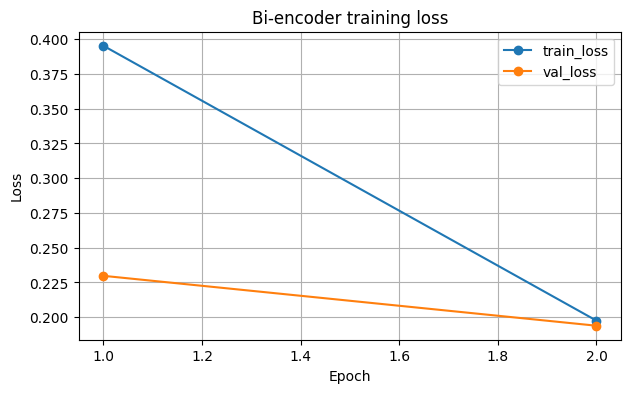

In [17]:
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
import pandas as pd

summary_path = RETRIEVER_DIR / "training_summary.json"
if not summary_path.exists():
    print("Training summary is not available yet:", summary_path)
else:
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    history = summary.get("history", [])
    if not history:
        print("Training summary has no history:", summary_path)
    else:
        loss_df = pd.DataFrame(history)
        ipy_display(loss_df)
        y_cols = [
            col
            for col in ["train_loss", "val_loss"]
            if col in loss_df.columns and loss_df[col].notna().any()
        ]
        ax = loss_df.plot(
            x="epoch",
            y=y_cols,
            marker="o",
            figsize=(7, 4),
            grid=True,
            title="Bi-encoder training loss",
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        plt.show()

## Build and save retrieval indices

Индексы кладутся в `artifacts/indices/<method>/...`. Hybrid-индекс сохраняется как manifest JSON плюс BM25/dense компоненты рядом с ним.

In [18]:
def build_index(
    method: str, retrieval_config: str, index_file: str, extra: list[str] | None = None
) -> dict:
    out_path = INDEX_ROOT / index_file
    overrides = base_overrides(artifacts_dir=INDEX_ROOT)
    overrides += [
        f"retrieval={retrieval_config}",
        "run.retrieval_index.corpus=data/processed/corpus.jsonl",
        f"retrieval.index_file={index_file}",
        f"run.retrieval_index.batch_size={ENCODE_BATCH_SIZE}",
    ]
    if extra:
        overrides += extra
    run_project("index", overrides)
    return {
        "method": method,
        "retrieval_config": retrieval_config,
        "index_file": index_file,
        "path": str(out_path),
        "extra_overrides": extra or [],
    }


trained_query_encoder = RETRIEVER_DIR / "query_encoder"
trained_doc_encoder = RETRIEVER_DIR / "doc_encoder"
trained_encoder_overrides = [
    f"retrieval.query_model_name={trained_query_encoder}",
    f"retrieval.doc_model_name={trained_doc_encoder}",
    f"run.retrieval_index.query_model={trained_query_encoder}",
    f"run.retrieval_index.doc_model={trained_doc_encoder}",
    "retrieval.local_files_only=true",
    "run.retrieval_index.local_files_only=true",
]

index_registry: dict[str, dict] = {}

specs = [
    ("bm25", "bm25", "bm25/bm25_index.json.gz", []),
    (
        "dense_minilm",
        "dense",
        "dense_minilm/dense_index.pkl",
        [
            "run.retrieval_index.model=sentence-transformers/all-MiniLM-L6-v2",
        ],
    ),
    ("medcpt_zero_shot", "medcpt", "medcpt_zero_shot/medcpt_index.pkl", []),
    ("hybrid_minilm", "hybrid", "hybrid_minilm/hybrid_index.json", []),
    (
        "hybrid_medcpt_zero_shot",
        "hybrid_medcpt",
        "hybrid_medcpt_zero_shot/hybrid_index.json",
        [],
    ),
]

if trained_query_encoder.exists() and trained_doc_encoder.exists():
    specs.extend(
        [
            (
                "trained_medcpt",
                "medcpt",
                "trained_medcpt/medcpt_index.pkl",
                trained_encoder_overrides,
            ),
            (
                "hybrid_trained_medcpt",
                "hybrid_medcpt",
                "hybrid_trained_medcpt/hybrid_index.json",
                trained_encoder_overrides,
            ),
        ]
    )
else:
    print("Trained encoder dirs are absent; trained_medcpt indices will be skipped.")

for method, retrieval_config, index_file, extra in specs:
    print("\n== Building", method, "==")
    index_registry[method] = build_index(method, retrieval_config, index_file, extra)

print("Built indices:", sorted(index_registry))


== Building bm25 ==
+ /usr/bin/python3 -u -m medical_rag_reranker.commands index --overrides ["data.use_dvc=false", "data.processed_dir=data/processed", "paths.artifacts_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices", "paths.runs_dir=/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/runs", "run.prep_data.out_dir=data/processed", "retrieval=bm25", "run.retrieval_index.corpus=data/processed/corpus.jsonl", "retrieval.index_file=bm25/bm25_index.json.gz", "run.retrieval_index.batch_size=32"]
Build bm25 index: started

Building BM25 index: 100%|██████████| 16407/16407 [00:00<00:00, 27506.78doc/s]
Build bm25 index: done in 1.6s
Saved index to: /content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/bm25/bm25_index.json.gz
/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/bm25/bm25_index.json.gz

== Building dense_minilm ==
+ /usr/bin/python3 -u -m medical_rag_reranker.comma

## Build graph metadata index

Это лёгкий graph-aware baseline: граф строится по metadata связям документов (`diagnosis_or_topic`, `question_intent`, `group_id`). В следующем ноутбуке он будет расширять кандидатов из BM25/hybrid run-файлов и оцениваться теми же TREC-метриками.

In [19]:
from collections import defaultdict
import re


def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def normalize_entity(value: object) -> str:
    text = re.sub(r"\s+", " ", str(value or "").strip().lower())
    text = text.strip(" .,:;!?()[]{}")
    return text


def build_graph_metadata_index(corpus_path: Path, out_path: Path) -> dict:
    rows = read_jsonl(corpus_path)
    entity_to_doc_ids: dict[str, list[str]] = defaultdict(list)
    doc_to_entities: dict[str, list[str]] = {}

    fields = ["diagnosis_or_topic", "question_intent", "group_id"]
    for row in rows:
        doc_id = str(row.get("doc_id") or "").strip()
        if not doc_id:
            continue
        entities = []
        for field in fields:
            value = normalize_entity(row.get(field))
            if not value:
                continue
            entity = f"{field}:{value}"
            entities.append(entity)
            entity_to_doc_ids[entity].append(doc_id)
        doc_to_entities[doc_id] = sorted(set(entities))

    payload = {
        "format": "medical-rag-reranker.metadata-graph-index",
        "version": 1,
        "corpus_path": str(corpus_path),
        "fields": fields,
        "relation_weights": {
            "diagnosis_or_topic": 0.45,
            "group_id": 0.35,
            "question_intent": 0.20,
        },
        "doc_to_entities": doc_to_entities,
        "entity_to_doc_ids": {
            key: sorted(set(value)) for key, value in entity_to_doc_ids.items()
        },
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return payload


graph_index_path = INDEX_ROOT / "graph_metadata" / "graph_index.json"
graph_payload = build_graph_metadata_index(
    PROJECT_PROCESSED_DIR / "corpus.jsonl", graph_index_path
)
index_registry["graph_metadata"] = {
    "method": "graph_metadata",
    "retrieval_config": "run_file_graph_expansion",
    "index_file": "graph_metadata/graph_index.json",
    "path": str(graph_index_path),
    "num_docs": len(graph_payload["doc_to_entities"]),
    "num_entities": len(graph_payload["entity_to_doc_ids"]),
}
print("Graph index:", graph_index_path)
print(
    "Graph docs/entities:",
    len(graph_payload["doc_to_entities"]),
    len(graph_payload["entity_to_doc_ids"]),
)

Graph index: /content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/graph_metadata/graph_index.json
Graph docs/entities: 16407 8241


In [20]:
manifest = {
    "run_id": RUN_ID,
    "created_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "repo_url": REPO_URL,
    "branch": BRANCH,
    "drive_root": str(DRIVE_ROOT),
    "project_dir_expected_in_colab": str(PROJECT_DIR),
    "data": {
        "processed_project_dir": str(PROJECT_PROCESSED_DIR),
        "processed_drive_dir": str(PROCESSED_DRIVE_DIR),
        "corpus": str(PROJECT_PROCESSED_DIR / "corpus.jsonl"),
        "eval_queries": str(PROJECT_PROCESSED_DIR / "eval_queries.jsonl"),
        "qrels": str(PROJECT_PROCESSED_DIR / "qrels.tsv"),
    },
    "models": {
        "trained_medcpt_biencoder": {
            "root": str(RETRIEVER_DIR),
            "query_encoder": str(RETRIEVER_DIR / "query_encoder"),
            "doc_encoder": str(RETRIEVER_DIR / "doc_encoder"),
            "training_summary": str(RETRIEVER_DIR / "training_summary.json"),
        }
    },
    "indices": index_registry,
    "runs_dir": str(RUN_ROOT),
    "notes": [
        "Keep this manifest with the Drive folder; later notebooks use it as the source of truth.",
        "BM25 index stores a corpus path. Later notebooks restore data/processed into /content/medical-rag-reranker before loading it.",
    ],
}
MANIFEST_PATH.write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Saved manifest:", MANIFEST_PATH)
print(
    json.dumps(
        {k: v["path"] for k, v in index_registry.items()}, ensure_ascii=False, indent=2
    )
)

Saved manifest: /content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/manifest.json
{
  "bm25": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/bm25/bm25_index.json.gz",
  "dense_minilm": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/dense_minilm/dense_index.pkl",
  "medcpt_zero_shot": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/medcpt_zero_shot/medcpt_index.pkl",
  "hybrid_minilm": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/hybrid_minilm/hybrid_index.json",
  "hybrid_medcpt_zero_shot": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/hybrid_medcpt_zero_shot/hybrid_index.json",
  "trained_medcpt": "/content/drive/MyDrive/medical-rag-reranker-colab/medquad_full_v1/artifacts/indices/trained_medcpt/medcpt_index.pkl",
  "hybrid_trained_medcpt": "/content/drive/MyDrive/medical-rag-rerank

/tmp/ipykernel_47422/1534372449.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",


## Push training artifacts to S3/DVC

Run this after training/indexing succeeds so local and Airflow runs can pull the finished artifacts.

In [21]:
subprocess.run(
    [sys.executable, "-m", "medical_rag_reranker.commands", "artifact_push"],
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'medical_rag_reranker.commands', 'artifact_push'], returncode=0)